#Experiment 10
###Analyze the Loss Functions Used in GAN Training (Adversarial Loss, Feature Matching Loss)

In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, _), (_, _) = mnist.load_data()

X_train = (X_train.astype("float32") - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
def build_generator():

    model = models.Sequential([
        layers.Dense(256, input_dim=100),
        layers.LeakyReLU(0.2),

        layers.Dense(512),
        layers.LeakyReLU(0.2),

        layers.Dense(28*28, activation='tanh'),
        layers.Reshape((28,28,1))
    ])

    return model

In [4]:
def build_discriminator():

    model = models.Sequential([
        layers.Flatten(input_shape=(28,28,1)),

        layers.Dense(512),
        layers.LeakyReLU(0.2),

        layers.Dense(256),
        layers.LeakyReLU(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    return model

In [5]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
discriminator.trainable = False

gan_input = layers.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = models.Model(gan_input, gan_output)

gan.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
epochs = 3000
batch_size = 64

d_losses = []
g_losses = []

In [8]:
for epoch in range(epochs):

    # Train Discriminator

    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator

    noise = np.random.normal(0,1,(batch_size,100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    d_losses.append(d_loss[0])
    g_losses.append(g_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f} | G Loss: {g_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 1.1346 | G Loss: 0.7452
Epoch 500 | D Loss: 7.3054 | G Loss: 0.0022
Epoch 1000 | D Loss: 7.3943 | G Loss: 0.0011
Epoch 1500 | D Loss: 7.4542 | G Loss: 0.0007
Epoch 2000 | D Loss: 7.5079 | G Loss: 0.0005
Epoch 2500 | D Loss: 7.5597 | G Loss: 0.0004


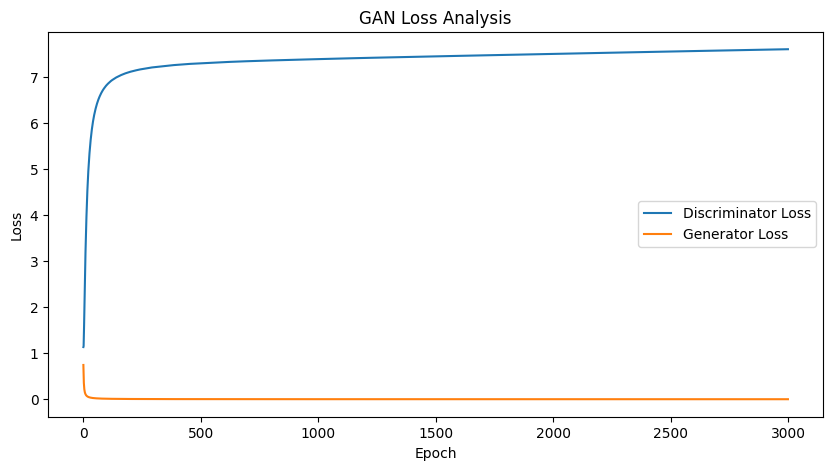

In [9]:
plt.figure(figsize=(10,5))

plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')

plt.title("GAN Loss Analysis")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Feature Matching Loss:

Instead of fooling discriminator directly, generator tries to match internal features.

In [14]:
feature_model = models.Model(
    inputs=discriminator.layers[0].input,
    outputs=discriminator.layers[-2].output
)

In [15]:
def feature_matching_loss(real, fake):

    real_features = feature_model(real)
    fake_features = feature_model(fake)

    return tf.reduce_mean(tf.square(real_features - fake_features))

In [16]:
# Demonstartion
noise = np.random.normal(0,1,(64,100))
fake_imgs = generator.predict(noise)

real_imgs = X_train[:64]

fm_loss = feature_matching_loss(real_imgs, fake_imgs)

print("Feature Matching Loss:", fm_loss.numpy())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Feature Matching Loss: 1.583615
